In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("cleaned_Interns_data.csv")

In [43]:
# Basic understanding
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   intern_id                50 non-null     int64  
 1   name                     50 non-null     object 
 2   Internship domain        50 non-null     object 
 3   attendance               50 non-null     float64
 4   tasks_assigned           50 non-null     int64  
 5   tasks_completed          50 non-null     int64  
 6   performance_score        50 non-null     int64  
 7   working_hours            50 non-null     int64  
 8   mentor_feedback          50 non-null     float64
 9   stipend                  50 non-null     int64  
 10  sprint_number            50 non-null     int64  
 11  sprint_status            50 non-null     object 
 12  total_sprints_completed  50 non-null     int64  
 13  task_completion_rate     50 non-null     float64
 14  efficiency_score         50 

In [44]:
# Create KPI columns
df["task_completion_rate"] = (df["tasks_completed"] / df["tasks_assigned"]) * 100
df["efficiency_score"] = (df["performance_score"] * 0.6) + (df["attendance"] * 0.4)


In [45]:
# Top performers
print("Top 10 Performers:")
print(df.nlargest(10, "performance_score")[["name", "performance_score"]])


Top 10 Performers:
       name  performance_score
0     Aarav                  9
2     Kavin                  9
5     Priya                  9
8    Vikram                  9
10    Surya                  9
13    Divya                  9
16  Karthik                  9
18     Ajay                  9
21     Neha                  9
25   Swathi                  9


In [46]:
# Performance distribution
print("\nPerformance Category Count:")
print(df["performance_category"].value_counts())


Performance Category Count:
performance_category
High      31
Medium    19
Name: count, dtype: int64


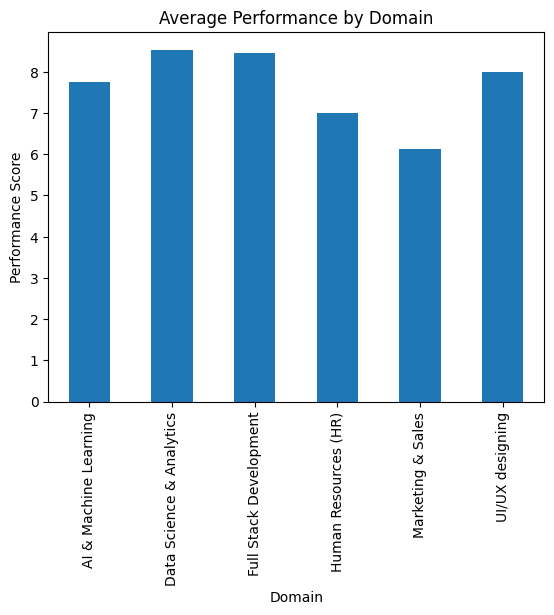

In [47]:
# Domain vs performance
df.groupby("Internship domain")["performance_score"].mean().plot(kind="bar")
plt.title("Average Performance by Domain")
plt.xlabel("Domain")
plt.ylabel("Performance Score")
plt.show()

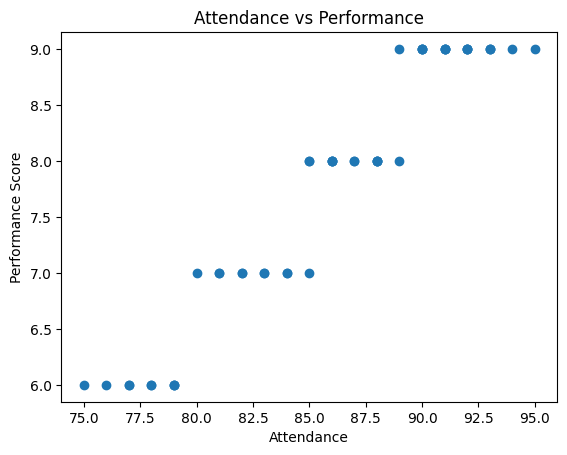

In [48]:
# Attendance vs performance
plt.scatter(df["attendance"], df["performance_score"])
plt.xlabel("Attendance")
plt.ylabel("Performance Score")
plt.title("Attendance vs Performance")
plt.show()

In [49]:
# Sprint status analysis
print("\nPerformance by Sprint Status:")
print(df.groupby("sprint_status")["performance_score"].mean())


Performance by Sprint Status:
sprint_status
Blocked        6.000000
Completed      8.533333
In Progress    6.857143
Not Started    6.666667
Name: performance_score, dtype: float64


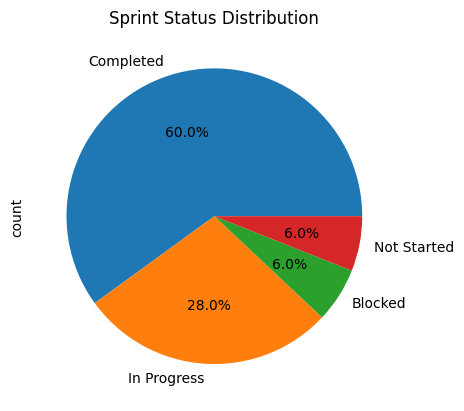

In [50]:
df["sprint_status"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Sprint Status Distribution")
plt.show()

In [51]:
# Task completion analysis
print("\nTop Task Completion:")
print(df.nlargest(5, "task_completion_rate")[["name", "task_completion_rate"]])



Top Task Completion:
         name  task_completion_rate
2       Kavin             95.454545
42     Dinesh             95.454545
25     Swathi             95.238095
45  Aishwarya             95.238095
5       Priya             95.000000


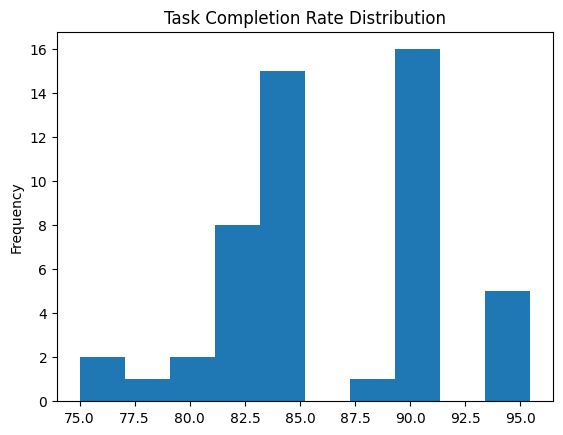

In [52]:
df["task_completion_rate"].plot(kind="hist")
plt.title("Task Completion Rate Distribution")
plt.show()

In [53]:
# Risk interns
risk = df[(df["performance_score"] < 6) & (df["attendance"] < 80) & (df["sprint_status"] != "Completed")]
print("\nRisk Interns:")
print(risk[["name", "performance_score", "attendance", "sprint_status"]])


Risk Interns:
Empty DataFrame
Columns: [name, performance_score, attendance, sprint_status]
Index: []


In [54]:
# High potential interns
high_potential = df[(df["performance_score"] >= 8) & (df["mentor_feedback"] >= 4)]
print("\nHigh Potential Interns:")
print(high_potential[["name", "performance_score", "mentor_feedback"]])


High Potential Interns:
         name  performance_score  mentor_feedback
0       Aarav                  9              5.0
2       Kavin                  9              5.0
4       Arjun                  8              4.0
5       Priya                  9              5.0
8      Vikram                  9              5.0
9      Ananya                  8              4.0
10      Surya                  9              5.0
12       Ravi                  8              4.0
13      Divya                  9              5.0
16    Karthik                  9              5.0
17      Pooja                  8              4.0
18       Ajay                  9              5.0
20     Sanjay                  8              4.0
21       Neha                  9              5.0
24      Rohit                  8              4.0
25     Swathi                  9              5.0
28    Praveen                  9              5.0
29        Anu                  8              4.0
30      Gokul            

In [55]:
# Correlation analysis
print("\nCorrelation Matrix:")
print(df[["attendance", "performance_score", "mentor_feedback"]].corr())


Correlation Matrix:
                   attendance  performance_score  mentor_feedback
attendance           1.000000           0.964218         0.907669
performance_score    0.964218           1.000000         0.933257
mentor_feedback      0.907669           0.933257         1.000000


In [56]:
eligible = df[(df["performance_score"] >= 8) & (df["attendance"] >= 85) & (df["sprint_status"] == "Completed") & (df["task_completion_rate"] >= 85)]

print("\nEligible Interns:")
print(eligible[["name", "performance_score", "attendance"]])

fte_final = eligible.nlargest(10, "performance_score")

print("\nFinal Selected Interns for FTE:")
print(fte_final[["name", "Internship domain", "performance_score"]])

df["FTE_Selected"] = df["name"].isin(fte_final["name"]).map({True: "Yes", False: "No"})

print("\nFTE Selection Count:")
print(df["FTE_Selected"].value_counts())


Eligible Interns:
         name  performance_score  attendance
0       Aarav                  9        92.0
2       Kavin                  9        95.0
4       Arjun                  8        88.0
5       Priya                  9        90.0
8      Vikram                  9        91.0
10      Surya                  9        93.0
12       Ravi                  8        85.0
13      Divya                  9        89.0
16    Karthik                  9        90.0
18       Ajay                  9        94.0
20     Sanjay                  8        88.0
21       Neha                  9        91.0
24      Rohit                  8        89.0
25     Swathi                  9        92.0
28    Praveen                  9        93.0
30      Gokul                  9        90.0
32      Vijay                  8        86.0
33     Shreya                  9        91.0
36    Aravind                  9        92.0
37   Nandhini                  8        88.0
40     Logesh                  9    

In [57]:
df.to_csv("final_analysis_data.csv", index=False)
